In [3]:
import numpy as np
import matplotlib.pyplot as plt
from ase import build
from ase.visualize import view
from ase.io import read

In [4]:
from skimage.io import imread,imsave
from skimage.draw import disk # cria um disco, utilizado para representar cada átomo
from skimage.color import label2rgb

## Máscara de átomos

In [5]:
atoms = read('mos2_defects.poscar') # lê o arquivo .poscar

In [6]:
## CONDIÇÕES PERIÓDICAS DE CONTORNO: átomos de borda são cortados, então criamos e apagamos uma supercélula para que o ASE interprete esses átomos como objetos inteiros

sc_atoms = atoms.copy() 
sc_atoms *= (2,2,1) #cria uma supercélula
sc_atoms_positions = sc_atoms.get_positions() #obtem as posições/coordenadas dos átomos

overcell_index = np.unique(np.append((sc_atoms_positions[:,0] > atoms.cell.array[0,0]+0.01).nonzero()[0],(sc_atoms_positions[:,1] > atoms.cell.array[1,1]+0.01).nonzero()[0]))
# atoms.cell.array: matriz diagonal com o comprimento da célula em cada eixo (angstroms?)
# sc_atoms_positions[:,e] :  varre a posição dos átomos em cada eixo 
# > atoms.cell..array[e,e] + 0.01: verifica se a posição do átomo está fora da célula original, e marca como True
# .nonzero()[0]: retorna os índices dos átomos que estão fora da célula original
# np.append(...): concatena os índices dos átomos que estão fora da célula original
# np.unique(...): remove repetições

del sc_atoms[overcell_index] # remove os átomos fora da célula original
sc_atoms.set_cell(atoms.cell.array) # determina o tamanho da célula como o tamanho da célula original

atoms = sc_atoms.copy()

In [7]:
# lê a imagem e salva como .png
tem_img = imread('mos2_computem_teste4.tif').T
imsave('mos2_defects_computem_teste4.png',tem_img)
tem_img.shape


(5760, 4988)

In [8]:
img_size = tem_img.shape
pixel_size = img_size / np.array([atoms.cell.array[0,0],atoms.cell.array[1,1]]) # tamanho do pixel = número de pixels / tamanho físico da célula (angstroms)
pixel_size

array([45.28301887, 45.28023809])

In [9]:
atoms_pixel_coords = np.rint(atoms.get_positions()[:,[0,1]] * pixel_size) # converte coordenadas de angstrons para pixel

In [10]:
#determina um objeto máscara, inicialmente toda rotulada como background (2)
mask_img = np.ones((img_size[0],img_size[1], 1), dtype=int) * 2
mask_img.shape

(5760, 4988, 1)

In [11]:
# determina o raio de cada átomo
atomic_radii = {'C': 0.73,'B': 0.82,'N': 0.70,'Mo': 0.95, 'S': 0.56} #diminui os raios tabulados para reproduzir o raio atômico nas imagens

In [12]:
# converte os raios atômicos de angstrom para pixel
mask_radius_mo = int(np.rint(pixel_size[0] * atomic_radii['Mo']))
mask_radius_s = int(np.rint(pixel_size[0] * atomic_radii['S']))
mask_radius_mo,mask_radius_s

(43, 25)

In [13]:
chemical_symbols = atoms.get_chemical_symbols() #resgata os símbolos químicos dos átomos

# cria a máscara, determinando o raio e o rótulo de cada átomo
for io in range(len(atoms_pixel_coords)):
    if chemical_symbols[io] == 'Mo':
        mask_radius = mask_radius_mo
        label = 1
    else:
        mask_radius = mask_radius_s
        label = 0
    rr, cc = disk( # cria a máscara do átomo como um disco. rr e cc são as coordenadas dos pixels rotulados
        (int(atoms_pixel_coords[io,0]), int(atoms_pixel_coords[io,1])), #coordenadas em pixel do centro do átomo
         mask_radius, #raio do átomo/disco
         shape=mask_img.shape) #tamanho da máscara na qual se cria o disco
    mask_img[rr, cc, :] = label # substitui os pixels do disco pelo rótulo do átomo (0 para S, 1 para Mo)

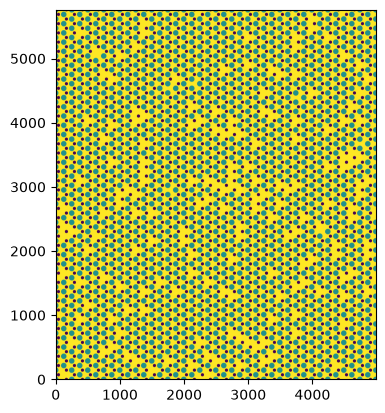

In [14]:
plt.imshow(mask_img,origin='lower'); plt.show() #visualização colorida

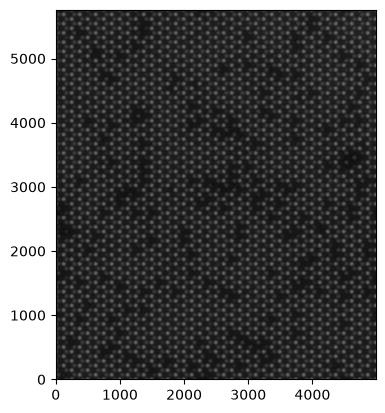

In [15]:
plt.imshow(tem_img,cmap='grey',origin='lower') #visualização imagem original

In [16]:
# transforma as labels em rgb para salvar a imagem
rgb_mask_img = (label2rgb(
    mask_img, #máscara
    bg_label=2, #rótulo do background
    colors=['blue','red'] #cores dos rótulos não fundo
    ).reshape((mask_img.shape[0],mask_img.shape[1],3)) * 255).astype(np.uint8) 
    # redimensiona a máscara, multiplica os pixels por 255 (rgb), e converte float para unit8 (255 valores)
    # essa redimensionalização garante o formato final da máscara, já q uma nova dimensão é criada (3 canais rgb), mas a imagem e a máscara já são tridimensionais (x,y,1)

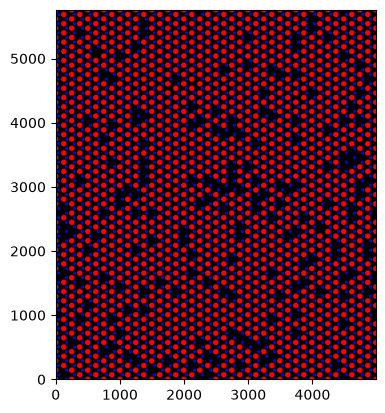

In [17]:
plt.imshow(rgb_mask_img,origin='lower') #visualização máscara rgb

In [18]:
imsave('mos2_labels_imagem4.png',rgb_mask_img) #salva a máscara rgb

## Máscara de Defeitos

In [19]:
atoms = read('mos2_defects_pos.poscar') #importa o .poscar só de defeitos

atoms_pixel_coords = np.rint(atoms.get_positions()[:,[0,1]] * pixel_size) #coordenadas em angstroms para coordenadas em pixels

In [20]:
## CONDIÇÕES PERIÓDICAS DE CONTORNO: átomos de borda são cortados, então criamos e apagamos uma supercélula para que o ASE interprete esses átomos como objetos inteiros

sc_atoms = atoms.copy() 
sc_atoms *= (2,2,1) #cria uma supercélula
sc_atoms_positions = sc_atoms.get_positions() #obtem as posições/coordenadas dos átomos

overcell_index = np.unique(np.append((sc_atoms_positions[:,0] > atoms.cell.array[0,0]+0.01).nonzero()[0],(sc_atoms_positions[:,1] > atoms.cell.array[1,1]+0.01).nonzero()[0]))
# atoms.cell.array: matriz diagonal com o comprimento da célula em cada eixo (angstroms?)
# sc_atoms_positions[:,e] :  varre a posição dos átomos em cada eixo 
# > atoms.cell..array[e,e] + 0.01: verifica se a posição do átomo está fora da célula original, e marca como True
# .nonzero()[0]: retorna os índices dos átomos que estão fora da célula original
# np.append(...): concatena os índices dos átomos que estão fora da célula original
# np.unique(...): remove repetições

del sc_atoms[overcell_index] # remove os átomos fora da célula original
sc_atoms.set_cell(atoms.cell.array) # determina o tamanho da célula como o tamanho da célula original

atoms = sc_atoms.copy()

In [21]:
# raios atomicos dos defeitos, com um aumento de 5% para melhor visualização
defect_radius_mo = int(np.rint(pixel_size[0] * atomic_radii['Mo'] * 1.05))
defect_radius_s = int(np.rint(pixel_size[0] * atomic_radii['S'] * 1.05))
defect_radius_mo,defect_radius_s

(45, 27)

In [22]:
# matriz de máscara/fundo
defect_mask_img = np.ones((img_size[0],img_size[1], 1), dtype=int) * 2
defect_mask_img.shape

(5760, 4988, 1)

In [23]:
chemical_symbols = atoms.get_chemical_symbols() # símbolos químicos

#cria a matriz de máscara com átomos em discos
for io in range(len(atoms_pixel_coords)):
    if chemical_symbols[io] == 'Mo':
        defect_radius = defect_radius_mo
        label = 1
    else:
        defect_radius = defect_radius_s
        label = 0
    rr, cc = disk((int(atoms_pixel_coords[io,0]), int(atoms_pixel_coords[io,1])), defect_radius, shape=defect_mask_img.shape)

    defect_mask_img[rr, cc, :] = label #define as labels dos discos criados na máscara

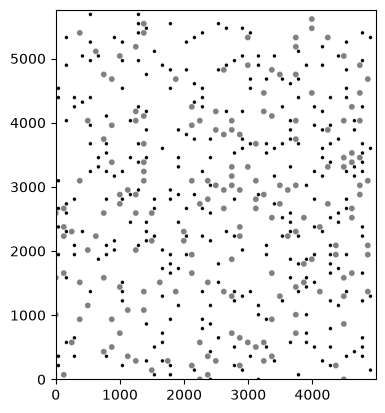

In [24]:
plt.imshow(defect_mask_img,cmap='grey',origin='lower')

In [25]:
#converte a imagem para rgb
rgb_defect_mask_img = (label2rgb(defect_mask_img,bg_label=2,colors=['blue','red',]).reshape((defect_mask_img.shape[0],defect_mask_img.shape[1],3)) * 255).astype(np.uint8)

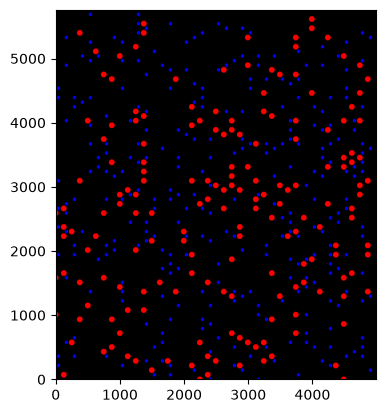

In [26]:
plt.imshow(rgb_defect_mask_img,origin='lower')

In [27]:
imsave('mos2_defects_labels_imagem4.png',rgb_defect_mask_img)

## Máscara de Defeitos de Enxofre

In [28]:
atoms = read('mos2_defects_pos.poscar') #importa o .poscar só de defeitos

chemical_symbols = atoms.get_chemical_symbols()  # símbolos químicos

s_atoms = atoms[[s == "S" for s in chemical_symbols]] #seleciona os átomos de enxofre

s_pixel_coords = np.rint(s_atoms.get_positions()[:,[0,1]] * pixel_size) #coordenadas em angstroms para coordenadas em pixels

In [29]:
## CONDIÇÕES PERIÓDICAS DE CONTORNO: átomos de borda são cortados, então criamos e apagamos uma supercélula para que o ASE interprete esses átomos como objetos inteiros

sc_atoms = atoms.copy() 
sc_atoms *= (2,2,1) #cria uma supercélula
sc_atoms_positions = sc_atoms.get_positions() #obtem as posições/coordenadas dos átomos

overcell_index = np.unique(np.append((sc_atoms_positions[:,0] > atoms.cell.array[0,0]+0.01).nonzero()[0],(sc_atoms_positions[:,1] > atoms.cell.array[1,1]+0.01).nonzero()[0]))
# atoms.cell.array: matriz diagonal com o comprimento da célula em cada eixo (angstroms?)
# sc_atoms_positions[:,e] :  varre a posição dos átomos em cada eixo 
# > atoms.cell..array[e,e] + 0.01: verifica se a posição do átomo está fora da célula original, e marca como True
# .nonzero()[0]: retorna os índices dos átomos que estão fora da célula original
# np.append(...): concatena os índices dos átomos que estão fora da célula original
# np.unique(...): remove repetições

del sc_atoms[overcell_index] # remove os átomos fora da célula original
sc_atoms.set_cell(atoms.cell.array) # determina o tamanho da célula como o tamanho da célula original

atoms = sc_atoms.copy()

In [30]:
# raio atomico dos defeitos de enxofre, com um aumento de 5% para melhor visualização
defect_S_radius = int(np.rint(pixel_size[0] * atomic_radii['S'] * 1.05))

In [31]:
# matriz de máscara/fundo
defect_S_mask_img = np.ones((img_size[0],img_size[1], 1), dtype=int) * 3
defect_S_mask_img.shape

(5760, 4988, 1)

In [32]:
defect_radius = defect_S_radius

z_positions = s_atoms.get_positions()[:,2] # altura dos átomos

#cria a matriz de máscara com átomos em discos
for io in range(len(s_pixel_coords)):
    
    if round(z_positions[io], 5) == round(min(z_positions), 5): #se S na camada inferior
        label = 0
    elif round(z_positions[io], 5) == round(max(z_positions), 5): # se S na camada superiro
        label = 1

    rr, cc = disk((int(s_pixel_coords[io,0]), int(s_pixel_coords[io,1])), defect_radius, shape=defect_mask_img.shape)

    #define as labels dos discos criados na máscara
    if np.all(defect_S_mask_img[rr, cc, :] == 3): #se o pixel não tiver sido rotulado
        defect_S_mask_img[rr, cc, :] = label #define uma nova label, de defeito duplo
    else:
        defect_S_mask_img[rr, cc, :] = 2

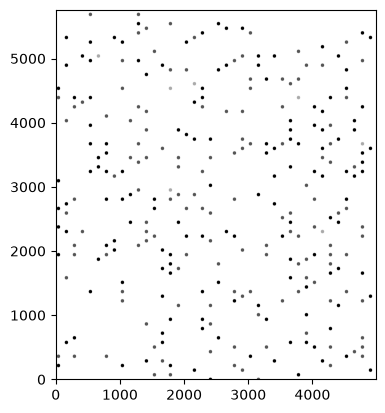

In [33]:
plt.imshow(defect_S_mask_img,cmap='grey',origin='lower')

In [34]:
#converte a imagem para rgb
rgb_S_defect_mask_img = (label2rgb(defect_S_mask_img,bg_label=3,colors=['blue','red','green','black']).reshape((defect_mask_img.shape[0],defect_mask_img.shape[1],3)) * 255).astype(np.uint8)

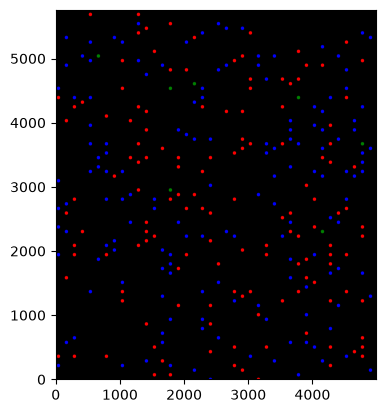

In [35]:
plt.imshow(rgb_S_defect_mask_img,origin='lower')

In [36]:
imsave('mos2_S_defects_labels_imagem4.png',rgb_S_defect_mask_img)

### Arquivo com as imagem, as labels, e a imagem rgb

In [37]:
np.savez('mos2_labels_imagem4.npz',**{'image': tem_img,'labels': mask_img, 'labels_defects': defect_mask_img,'labels_S_defects': defect_S_mask_img, 'rgb_img': rgb_mask_img,'rgb_defects_img': rgb_defect_mask_img, 'rgb_S_defects_img': rgb_S_defect_mask_img})

In [38]:
view(atoms)

<Popen: returncode: None args: ['c:\\Users\\julia24002\\.conda\\envs\\ase\\p...>